# Pandas vs Polars en Colab  
## Notebook completo para practicar diferencias, funciones principales, lazy execution y una introducción a RDDs

Este notebook está pensado para que el alumnado:
- aprenda las operaciones más habituales de **Pandas** y **Polars**
- compare su sintaxis y filosofía de trabajo
- entienda cuándo conviene usar una u otra librería
- vea qué es **lazy execution** en Polars
- y descubra la idea de **RDDs** en PySpark como puente hacia Big Data

---
### Objetivos
Al final de esta práctica deberías ser capaz de:
1. Cargar datos con Pandas y Polars.
2. Inspeccionar, filtrar, ordenar y transformar datos.
3. Agrupar y agregar información.
4. Trabajar con cadenas, listas y valores nulos.
5. Comparar la sintaxis entre ambas herramientas.
6. Entender la diferencia entre ejecución **eager** y **lazy**.
7. Comprender qué es un **RDD** y cómo se relaciona con el modelo MapReduce.

## 1. Preparación del entorno

En Google Colab suele hacer falta instalar algunas librerías manualmente.  
Ejecuta la siguiente celda al principio.

In [ ]:
!pip -q install polars pyarrow pyspark

In [ ]:
import time
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
np.random.seed(42)

print("Pandas:", pd.__version__)
print("Polars:", pl.__version__)

Pandas: 2.2.2
Polars: 1.35.2


## 2. Crear un dataset de ejemplo

Vamos a generar un conjunto de datos sintético que se parezca a un caso real:
ventas, ciudades, categorías, descuentos, puntuaciones y etiquetas.

Esto nos permitirá practicar sin depender de archivos externos.

In [ ]:
n = 50_000

cities = np.random.choice(["Barcelona", "Madrid", "Valencia", "Sevilla", "Bilbao"], size=n)
categories = np.random.choice(["Tecnología", "Hogar", "Deporte", "Libros"], size=n)
products = np.random.choice(["A", "B", "C", "D", "E", "F"], size=n)
price = np.round(np.random.uniform(5, 500, size=n), 2)
quantity = np.random.randint(1, 10, size=n)
discount = np.round(np.random.choice([0, 0.05, 0.10, 0.15, 0.20], size=n), 2)
rating = np.round(np.random.uniform(1, 5, size=n), 1)

tags_pool = np.array(["nuevo", "oferta", "premium", "eco", "popular"])
tags = [list(np.random.choice(tags_pool, size=np.random.randint(1, 4), replace=False)) for _ in range(n)]

df_base = pd.DataFrame({
    "sale_id": np.arange(1, n + 1),
    "city": cities,
    "category": categories,
    "product": products,
    "price": price,
    "quantity": quantity,
    "discount": discount,
    "rating": rating,
    "tags": tags
})

# Añadimos algunos nulos para practicar limpieza de datos
null_idx = np.random.choice(df_base.index, size=1000, replace=False)
df_base.loc[null_idx[:300], "city"] = None
df_base.loc[null_idx[300:650], "rating"] = None
df_base.loc[null_idx[650:], "discount"] = None

df_base.head()

,sale_id,city,category,product,price,quantity,discount,rating,tags
0,1,Sevilla,Deporte,E,98.97,5,0.15,2.3,"[nuevo, premium, oferta]"
1,2,Bilbao,Deporte,D,454.51,5,0.15,2.9,"[popular, nuevo]"
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]"
3,4,Bilbao,Libros,B,314.54,7,0.15,1.3,"[nuevo, eco, oferta]"
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco]


## 3. Crear versiones en Pandas y Polars

Trabajaremos con el mismo dataset en ambas librerías para que la comparación sea justa.

In [ ]:
pdf = df_base.copy()
pldf = pl.from_pandas(df_base)

print("Shape Pandas:", pdf.shape)
print("Shape Polars:", pldf.shape)

Shape Pandas: (50000, 9)
Shape Polars: (50000, 9)


# 4. Inspección inicial de datos

## 4.1 Ver las primeras filas

In [ ]:
# Pandas
pdf.head()

,sale_id,city,category,product,price,quantity,discount,rating,tags
0,1,Sevilla,Deporte,E,98.97,5,0.15,2.3,"[nuevo, premium, oferta]"
1,2,Bilbao,Deporte,D,454.51,5,0.15,2.9,"[popular, nuevo]"
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]"
3,4,Bilbao,Libros,B,314.54,7,0.15,1.3,"[nuevo, eco, oferta]"
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco]


In [ ]:
# Polars
pldf.head()

sale_id,city,category,product,price,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,list[str]
1,"""Sevilla""","""Deporte""","""E""",98.97,5,0.15,2.3,"[""nuevo"", ""premium"", ""oferta""]"
2,"""Bilbao""","""Deporte""","""D""",454.51,5,0.15,2.9,"[""popular"", ""nuevo""]"
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"[""nuevo"", ""premium"", ""oferta""]"
4,"""Bilbao""","""Libros""","""B""",314.54,7,0.15,1.3,"[""nuevo"", ""eco"", ""oferta""]"
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"[""eco""]"


## 4.2 Tipos de datos

Una diferencia importante:
- **Pandas** usa `dtypes`
- **Polars** muestra sus tipos internos de forma más estricta y expresiva

In [ ]:
print("Pandas:")
print(pdf.dtypes)

Pandas:
sale_id       int64
city         object
category     object
product      object
price       float64
quantity      int64
discount    float64
rating      float64
tags         object
dtype: object


In [ ]:
print("Polars:")
print(pldf.schema)

Polars:
Schema({'sale_id': Int64, 'city': String, 'category': String, 'product': String, 'price': Float64, 'quantity': Int64, 'discount': Float64, 'rating': Float64, 'tags': List(String)})


## 4.3 Información general

Pandas tiene `info()`.  
Polars no usa exactamente el mismo estilo, pero podemos inspeccionar esquema, forma y nulos.

In [ ]:
pdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sale_id   50000 non-null  int64  
 1   city      49700 non-null  object 
 2   category  50000 non-null  object 
 3   product   50000 non-null  object 
 4   price     50000 non-null  float64
 5   quantity  50000 non-null  int64  
 6   discount  49650 non-null  float64
 7   rating    49650 non-null  float64
 8   tags      50000 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.4+ MB


In [ ]:
print("Filas y columnas:", pldf.shape)
print("Esquema:", pldf.schema)
print("Nulos por columna:")
print(pldf.null_count())

Filas y columnas: (50000, 9)
Esquema: Schema({'sale_id': Int64, 'city': String, 'category': String, 'product': String, 'price': Float64, 'quantity': Int64, 'discount': Float64, 'rating': Float64, 'tags': List(String)})
Nulos por columna:
shape: (1, 9)
┌─────────┬──────┬──────────┬─────────┬───┬──────────┬──────────┬────────┬──────┐
│ sale_id ┆ city ┆ category ┆ product ┆ … ┆ quantity ┆ discount ┆ rating ┆ tags │
│ ---     ┆ ---  ┆ ---      ┆ ---     ┆   ┆ ---      ┆ ---      ┆ ---    ┆ ---  │
│ u32     ┆ u32  ┆ u32      ┆ u32     ┆   ┆ u32      ┆ u32      ┆ u32    ┆ u32  │
╞═════════╪══════╪══════════╪═════════╪═══╪══════════╪══════════╪════════╪══════╡
│ 0       ┆ 300  ┆ 0        ┆ 0       ┆ … ┆ 0        ┆ 350      ┆ 350    ┆ 0    │
└─────────┴──────┴──────────┴─────────┴───┴──────────┴──────────┴────────┴──────┘


# 5. Selección de columnas

## Idea clave
- En **Pandas** solemos usar corchetes: `df[["col1", "col2"]]`
- En **Polars** se usa mucho `select()`

In [ ]:
# Pandas
pdf[["city", "category", "price"]].head()

,city,category,price
0,Sevilla,Deporte,98.97
1,Bilbao,Deporte,454.51
2,Valencia,Deporte,384.47
3,Bilbao,Libros,314.54
4,Bilbao,Deporte,474.37


In [ ]:
# Polars
pldf.select(["city", "category", "price"]).head()

city,category,price
str,str,f64
"""Sevilla""","""Deporte""",98.97
"""Bilbao""","""Deporte""",454.51
"""Valencia""","""Deporte""",384.47
"""Bilbao""","""Libros""",314.54
"""Bilbao""","""Deporte""",474.37


# 6. Filtrado de filas

Vamos a quedarnos con ventas de Barcelona con precio mayor que 200.

In [ ]:
# Pandas
pdf[(pdf["city"] == "Barcelona") & (pdf["price"] > 200)].head()

,sale_id,city,category,product,price,quantity,discount,rating,tags
23,24,Barcelona,Libros,E,418.24,6,0.05,4.1,"[premium, popular]"
24,25,Barcelona,Libros,B,330.83,9,NaN,4.9,"[oferta, nuevo, popular]"
33,34,Barcelona,Hogar,B,248.41,1,0.15,3.6,"[nuevo, eco, premium]"
38,39,Barcelona,Libros,B,255.66,1,0.10,1.1,"[popular, nuevo]"
41,42,Barcelona,Tecnología,F,485.74,5,0.20,4.0,"[oferta, nuevo]"


In [ ]:
# Polars
pldf.filter((pl.col("city") == "Barcelona") & (pl.col("price") > 200)).head()

sale_id,city,category,product,price,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,list[str]
24,"""Barcelona""","""Libros""","""E""",418.24,6,0.05,4.1,"[""premium"", ""popular""]"
25,"""Barcelona""","""Libros""","""B""",330.83,9,null,4.9,"[""oferta"", ""nuevo"", ""popular""]"
34,"""Barcelona""","""Hogar""","""B""",248.41,1,0.15,3.6,"[""nuevo"", ""eco"", ""premium""]"
39,"""Barcelona""","""Libros""","""B""",255.66,1,0.1,1.1,"[""popular"", ""nuevo""]"
42,"""Barcelona""","""Tecnología""","""F""",485.74,5,0.2,4.0,"[""oferta"", ""nuevo""]"


## Diferencia conceptual
- **Pandas** trabaja con máscaras booleanas usando Series.
- **Polars** trabaja con expresiones (`pl.col(...)`) que luego el motor optimiza.

# 7. Ordenación de datos

In [ ]:
# Pandas
pdf.sort_values(by="price", ascending=False).head()

,sale_id,city,category,product,price,quantity,discount,rating,tags
34310,34311,Bilbao,Deporte,D,499.97,4,0.20,4.8,[eco]
5002,5003,Sevilla,Hogar,E,499.96,8,0.10,3.5,[popular]
28404,28405,Madrid,Hogar,E,499.96,8,0.20,3.3,"[popular, nuevo]"
42056,42057,Sevilla,Libros,D,499.94,6,0.05,3.3,"[nuevo, eco, popular]"
42302,42303,Valencia,Hogar,A,499.91,9,0.05,2.7,"[nuevo, popular]"


In [ ]:
# Polars
pldf.sort("price", descending=True).head()

sale_id,city,category,product,price,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,list[str]
34311,"""Bilbao""","""Deporte""","""D""",499.97,4,0.2,4.8,"[""eco""]"
5003,"""Sevilla""","""Hogar""","""E""",499.96,8,0.1,3.5,"[""popular""]"
28405,"""Madrid""","""Hogar""","""E""",499.96,8,0.2,3.3,"[""popular"", ""nuevo""]"
42057,"""Sevilla""","""Libros""","""D""",499.94,6,0.05,3.3,"[""nuevo"", ""eco"", ""popular""]"
42303,"""Valencia""","""Hogar""","""A""",499.91,9,0.05,2.7,"[""nuevo"", ""popular""]"


# 8. Crear nuevas columnas

Vamos a crear:
- `total_bruto = price * quantity`
- `total_final = total_bruto * (1 - discount)`

In [ ]:
# Pandas
pdf_calc = pdf.copy()
pdf_calc["total_bruto"] = pdf_calc["price"] * pdf_calc["quantity"]
pdf_calc["total_final"] = pdf_calc["total_bruto"] * (1 - pdf_calc["discount"].fillna(0))
pdf_calc.head()

,sale_id,city,category,product,price,quantity,discount,rating,tags,total_bruto,total_final
0,1,Sevilla,Deporte,E,98.97,5,0.15,2.3,"[nuevo, premium, oferta]",494.85,420.6225
1,2,Bilbao,Deporte,D,454.51,5,0.15,2.9,"[popular, nuevo]",2272.55,1931.6675
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]",1922.35,1922.3500
3,4,Bilbao,Libros,B,314.54,7,0.15,1.3,"[nuevo, eco, oferta]",2201.78,1871.5130
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco],1897.48,1897.4800


In [ ]:
# Polars
pldf_calc = pldf.with_columns([
    (pl.col("price") * pl.col("quantity")).alias("total_bruto"),
    ((pl.col("price") * pl.col("quantity")) * (1 - pl.col("discount").fill_null(0))).alias("total_final")
])
pldf_calc.head()

sale_id,city,category,product,price,quantity,discount,rating,tags,total_bruto,total_final
i64,str,str,str,f64,i64,f64,f64,list[str],f64,f64
1,"""Sevilla""","""Deporte""","""E""",98.97,5,0.15,2.3,"[""nuevo"", ""premium"", ""oferta""]",494.85,420.6225
2,"""Bilbao""","""Deporte""","""D""",454.51,5,0.15,2.9,"[""popular"", ""nuevo""]",2272.55,1931.6675
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"[""nuevo"", ""premium"", ""oferta""]",1922.35,1922.35
4,"""Bilbao""","""Libros""","""B""",314.54,7,0.15,1.3,"[""nuevo"", ""eco"", ""oferta""]",2201.78,1871.513
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"[""eco""]",1897.48,1897.48


## Diferencia importante
- En **Pandas**, muchas veces modificamos el DataFrame paso a paso.
- En **Polars**, es muy habitual expresar transformaciones dentro de `with_columns()`.

# 9. Renombrar columnas

In [ ]:
# Pandas
pdf_ren = pdf.rename(columns={"city": "ciudad", "price": "precio"})
pdf_ren.head()

,sale_id,ciudad,category,product,precio,quantity,discount,rating,tags
0,1,Sevilla,Deporte,E,98.97,5,0.15,2.3,"[nuevo, premium, oferta]"
1,2,Bilbao,Deporte,D,454.51,5,0.15,2.9,"[popular, nuevo]"
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]"
3,4,Bilbao,Libros,B,314.54,7,0.15,1.3,"[nuevo, eco, oferta]"
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco]


In [ ]:
# Polars
pldf_ren = pldf.rename({"city": "ciudad", "price": "precio"})
pldf_ren.head()

sale_id,ciudad,category,product,precio,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,list[str]
1,"""Sevilla""","""Deporte""","""E""",98.97,5,0.15,2.3,"[""nuevo"", ""premium"", ""oferta""]"
2,"""Bilbao""","""Deporte""","""D""",454.51,5,0.15,2.9,"[""popular"", ""nuevo""]"
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"[""nuevo"", ""premium"", ""oferta""]"
4,"""Bilbao""","""Libros""","""B""",314.54,7,0.15,1.3,"[""nuevo"", ""eco"", ""oferta""]"
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"[""eco""]"


# 10. Valores nulos

Los nulos aparecen en proyectos reales constantemente.  
Vamos a inspeccionarlos y tratarlos.

In [ ]:
# Pandas: nulos por columna
pdf.isna().sum()

,0
sale_id,0
city,300
category,0
product,0
price,0
quantity,0
discount,350
rating,350
tags,0


In [ ]:
# Polars: nulos por columna
pldf.null_count()

sale_id,city,category,product,price,quantity,discount,rating,tags
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,300,0,0,0,0,350,350,0


In [ ]:
# Pandas: rellenar nulos
pdf_nulls = pdf.copy()
pdf_nulls["city"] = pdf_nulls["city"].fillna("Desconocida")
pdf_nulls["discount"] = pdf_nulls["discount"].fillna(0)
pdf_nulls["rating"] = pdf_nulls["rating"].fillna(pdf_nulls["rating"].mean())
pdf_nulls.head()

,sale_id,city,category,product,price,quantity,discount,rating,tags
0,1,Sevilla,Deporte,E,98.97,5,0.15,2.3,"[nuevo, premium, oferta]"
1,2,Bilbao,Deporte,D,454.51,5,0.15,2.9,"[popular, nuevo]"
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]"
3,4,Bilbao,Libros,B,314.54,7,0.15,1.3,"[nuevo, eco, oferta]"
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco]


In [ ]:
# Polars: rellenar nulos
pldf_nulls = pldf.with_columns([
    pl.col("city").fill_null("Desconocida"),
    pl.col("discount").fill_null(0),
    pl.col("rating").fill_null(pl.col("rating").mean())
])
pldf_nulls.head()

sale_id,city,category,product,price,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,list[str]
1,"""Sevilla""","""Deporte""","""E""",98.97,5,0.15,2.3,"[""nuevo"", ""premium"", ""oferta""]"
2,"""Bilbao""","""Deporte""","""D""",454.51,5,0.15,2.9,"[""popular"", ""nuevo""]"
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"[""nuevo"", ""premium"", ""oferta""]"
4,"""Bilbao""","""Libros""","""B""",314.54,7,0.15,1.3,"[""nuevo"", ""eco"", ""oferta""]"
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"[""eco""]"


# 11. Agrupación y agregaciones

Vamos a agrupar por ciudad y categoría, calculando:
- número de registros
- media de precio
- suma del total vendido

In [ ]:
# Pandas
pdf_group = pdf.copy()
pdf_group["total_bruto"] = pdf_group["price"] * pdf_group["quantity"]

grouped_pd = (
    pdf_group
    .groupby(["city", "category"], dropna=False)
    .agg(
        operaciones=("sale_id", "count"),
        precio_medio=("price", "mean"),
        ventas_totales=("total_bruto", "sum")
    )
    .reset_index()
    .sort_values("ventas_totales", ascending=False)
)

grouped_pd.head(10)

,city,category,operaciones,precio_medio,ventas_totales
6,Bilbao,Libros,2516,255.408203,3265214.32
10,Madrid,Libros,2529,252.933555,3224957.61
1,Barcelona,Hogar,2479,255.466321,3208548.32
12,Sevilla,Deporte,2503,254.753971,3204960.18
2,Barcelona,Libros,2510,254.475092,3177898.59
14,Sevilla,Libros,2507,253.516617,3172132.18
5,Bilbao,Hogar,2526,249.651465,3171091.44
13,Sevilla,Hogar,2521,251.056755,3165704.06
7,Bilbao,Tecnología,2550,248.970984,3165212.32
8,Madrid,Deporte,2454,252.240526,3121967.60


In [ ]:
# Polars
grouped_pl = (
    pldf
    .with_columns((pl.col("price") * pl.col("quantity")).alias("total_bruto"))
    .group_by(["city", "category"])
    .agg([
        pl.len().alias("operaciones"),
        pl.col("price").mean().alias("precio_medio"),
        pl.col("total_bruto").sum().alias("ventas_totales")
    ])
    .sort("ventas_totales", descending=True)
)

grouped_pl.head(10)

city,category,operaciones,precio_medio,ventas_totales
str,str,u32,f64,f64
"""Bilbao""","""Libros""",2516,255.408203,3.2652e6
"""Madrid""","""Libros""",2529,252.933555,3.2250e6
"""Barcelona""","""Hogar""",2479,255.466321,3.2085e6
"""Sevilla""","""Deporte""",2503,254.753971,3.2050e6
"""Barcelona""","""Libros""",2510,254.475092,3.1779e6
"""Sevilla""","""Libros""",2507,253.516617,3.1721e6
"""Bilbao""","""Hogar""",2526,249.651465,3.1711e6
"""Sevilla""","""Hogar""",2521,251.056755,3.1657e6
"""Bilbao""","""Tecnología""",2550,248.970984,3.1652e6


## Diferencia de nombres
- **Pandas**: `groupby`
- **Polars**: `group_by`

Parece una diferencia pequeña, pero conviene memorizarla porque da errores muy comunes.

# 12. Conteos y frecuencias

In [ ]:
# Pandas
pdf["category"].value_counts()

,count
category,
Hogar,12564
Tecnología,12559
Libros,12526
Deporte,12351


In [ ]:
# Polars
pldf["category"].value_counts()

category,count
str,u32
"""Hogar""",12564
"""Deporte""",12351
"""Libros""",12526
"""Tecnología""",12559


# 13. Operaciones con texto

Vamos a detectar productos cuyo nombre contenga una letra concreta o transformar texto.

In [ ]:
# Pandas
pdf[pdf["product"].str.contains("A", na=False)].head()

,sale_id,city,category,product,price,quantity,discount,rating,tags
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]"
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco]
6,7,Valencia,Deporte,A,319.46,4,0.00,5.0,"[oferta, nuevo]"
8,9,Valencia,Hogar,A,395.18,4,0.20,3.2,"[popular, nuevo, eco]"
26,27,Valencia,Libros,A,359.46,8,0.15,4.2,[oferta]


In [ ]:
# Polars
pldf.(plfilter.col("product").str.contains("A")).head()

sale_id,city,category,product,price,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,list[str]
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"[""nuevo"", ""premium"", ""oferta""]"
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"[""eco""]"
7,"""Valencia""","""Deporte""","""A""",319.46,4,0.0,5.0,"[""oferta"", ""nuevo""]"
9,"""Valencia""","""Hogar""","""A""",395.18,4,0.2,3.2,"[""popular"", ""nuevo"", ""eco""]"
27,"""Valencia""","""Libros""","""A""",359.46,8,0.15,4.2,"[""oferta""]"


# 14. Trabajar con listas: explode

La columna `tags` contiene listas.  
Vamos a separar cada etiqueta en una fila distinta con `explode`.

In [ ]:
# Pandas
pdf_tags = pdf.explode("tags")
pdf_tags[["sale_id", "tags"]].head(10)

,sale_id,tags
0,1,nuevo
0,1,premium
0,1,oferta
1,2,popular
1,2,nuevo
2,3,nuevo
2,3,premium
2,3,oferta
3,4,nuevo
3,4,eco


In [ ]:
# Polars
pldf_tags = pldf.explode("tags")
pldf_tags.select(["sale_id", "tags"]).head(10)

sale_id,tags
i64,str
1,"""nuevo"""
1,"""premium"""
1,"""oferta"""
2,"""popular"""
2,"""nuevo"""
3,"""nuevo"""
3,"""premium"""
3,"""oferta"""
4,"""nuevo"""


In [ ]:
# Contar etiquetas en Pandas
pdf_tags["tags"].value_counts()

,count
tags,
oferta,20066
eco,20019
popular,20001
nuevo,19912
premium,19875


In [ ]:
# Contar etiquetas en Polars
pldf_tags.group_by("tags").agg(pl.len().alias("conteo")).sort("conteo", descending=True)

tags,conteo
str,u32
"""oferta""",20066
"""eco""",20019
"""popular""",20001
"""nuevo""",19912
"""premium""",19875


# 15. Joins / merges

Vamos a crear una pequeña tabla externa con información por categoría y unirla a nuestro dataset.

In [ ]:
category_info_pd = pd.DataFrame({
    "category": ["Tecnología", "Hogar", "Deporte", "Libros"],
    "iva": [0.21, 0.10, 0.21, 0.04],
    "fragil": [True, True, False, False]
})

category_info_pl = pl.from_pandas(category_info_pd)

category_info_pd

,category,iva,fragil
0,Tecnología,0.21,True
1,Hogar,0.10,True
2,Deporte,0.21,False
3,Libros,0.04,False


In [ ]:
# Pandas merge
pdf_merge = pdf.merge(category_info_pd, on="category", how="left")
pdf_merge.head()

,sale_id,city,category,product,price,quantity,discount,rating,tags,iva,fragil
0,1,Sevilla,Deporte,E,98.97,5,0.15,2.3,"[nuevo, premium, oferta]",0.21,False
1,2,Bilbao,Deporte,D,454.51,5,0.15,2.9,"[popular, nuevo]",0.21,False
2,3,Valencia,Deporte,A,384.47,5,0.00,4.2,"[nuevo, premium, oferta]",0.21,False
3,4,Bilbao,Libros,B,314.54,7,0.15,1.3,"[nuevo, eco, oferta]",0.04,False
4,5,Bilbao,Deporte,A,474.37,4,0.00,4.5,[eco],0.21,False


In [ ]:
# Polars join
pldf_merge = pldf.join(category_info_pl, on="category", how="left")
pldf_merge.head()

sale_id,city,category,product,price,quantity,discount,rating,tags,iva,fragil
i64,str,str,str,f64,i64,f64,f64,list[str],f64,bool
1,"""Sevilla""","""Deporte""","""E""",98.97,5,0.15,2.3,"[""nuevo"", ""premium"", ""oferta""]",0.21,false
2,"""Bilbao""","""Deporte""","""D""",454.51,5,0.15,2.9,"[""popular"", ""nuevo""]",0.21,false
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"[""nuevo"", ""premium"", ""oferta""]",0.21,false
4,"""Bilbao""","""Libros""","""B""",314.54,7,0.15,1.3,"[""nuevo"", ""eco"", ""oferta""]",0.04,false
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"[""eco""]",0.21,false


# 16. Diferencias de estilo entre Pandas y Polars

## Pandas
- Muy extendido en ciencia de datos.
- Sintaxis flexible y familiar.
- Excelente integración con muchas librerías.
- Muy útil para enseñanza inicial y análisis exploratorio.
- Puede sufrir más con datasets muy grandes.

## Polars
- Más moderno y más estricto.
- Muy rápido en muchas operaciones.
- Usa expresiones y optimización interna.
- Muy potente para pipelines claros y reproducibles.
- Lazy execution permite optimizar aún más el flujo.

## Idea práctica
- **Pandas**: ideal para empezar y para ecosistema clásico de Python.
- **Polars**: ideal cuando queremos más rendimiento y pipelines limpios.

# 17. Comparación lado a lado de operaciones comunes

Esta tabla resume equivalencias frecuentes.

| Tarea | Pandas | Polars |
|---|---|---|
| Ver primeras filas | `df.head()` | `df.head()` |
| Seleccionar columnas | `df[["a","b"]]` | `df.select(["a","b"])` |
| Filtrar | `df[df["a"] > 5]` | `df.filter(pl.col("a") > 5)` |
| Ordenar | `df.sort_values("a")` | `df.sort("a")` |
| Nueva columna | `df["c"] = ...` | `df.with_columns(...alias("c"))` |
| Agrupar | `df.groupby("a").agg(...)` | `df.group_by("a").agg(...)` |
| Join | `df.merge(df2, ...)` | `df.join(df2, ...)` |
| Nulos | `fillna()` | `fill_null()` |
| Explode | `explode()` | `explode()` |

# 18. Rendimiento: pequeño benchmark

No todos los benchmarks son justos, pero sirven para ver tendencias.  
Vamos a comparar una operación con volumen relativamente alto.

In [ ]:
n_big = 1_000_000

big_df = pd.DataFrame({
    "group": np.random.randint(0, 100, size=n_big),
    "x": np.random.rand(n_big),
    "y": np.random.rand(n_big)
})

big_pl = pl.from_pandas(big_df)

# Pandas
start = time.time()
result_pd = (
    big_df[big_df["x"] > 0.5]
    .groupby("group")
    .agg({"y": "mean"})
    .reset_index()
)
pd_time = time.time() - start

# Polars
start = time.time()
result_pl = (
    big_pl
    .filter(pl.col("x") > 0.5)
    .group_by("group")
    .agg(pl.col("y").mean().alias("y_mean"))
)
pl_time = time.time() - start

print(f"Tiempo Pandas: {pd_time:.4f} s")
print(f"Tiempo Polars: {pl_time:.4f} s")

Tiempo Pandas: 0.1045 s
Tiempo Polars: 0.0486 s


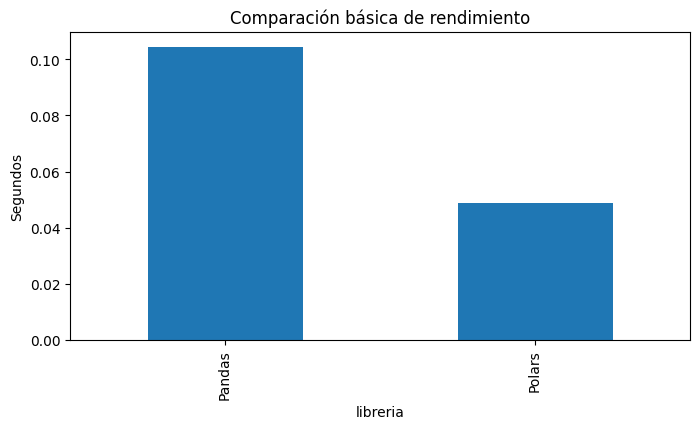

In [ ]:
times = pd.DataFrame({
    "libreria": ["Pandas", "Polars"],
    "tiempo_segundos": [pd_time, pl_time]
})

times.plot(kind="bar", x="libreria", y="tiempo_segundos", legend=False)
plt.ylabel("Segundos")
plt.title("Comparación básica de rendimiento")
plt.show()

## Interpretación del benchmark
Si Polars sale más rápido, no significa que siempre vaya a ganar en cualquier caso.  
El rendimiento depende de:
- tamaño del dataset
- tipo de operación
- hardware
- formato de entrada
- y pipeline realizado

Lo importante es entender que **Polars está diseñado con un motor más moderno y optimizado**.

# 19. Eager vs Lazy execution en Polars

## Eager execution
La operación se ejecuta inmediatamente.

## Lazy execution
Las operaciones se registran como un plan.  
No se ejecutan hasta que llamamos a `collect()`.

### ¿Por qué es útil?
Porque Polars puede:
- reorganizar operaciones
- eliminar pasos innecesarios
- aplicar optimizaciones
- y leer solo lo necesario

Esto se parece a lo que hacen motores de consulta más avanzados.

In [ ]:
# Ejecución eager
eager_result = (
    pldf
    .filter(pl.col("price") > 100)
    .group_by("city")
    .agg(pl.col("quantity").sum().alias("cantidad_total"))
)

eager_result.head()

city,cantidad_total
str,i64
"""Sevilla""",40124
null,1218
"""Barcelona""",40258
"""Bilbao""",40639
"""Valencia""",39112


In [ ]:
# Ejecución lazy
lazy_result = (
    pldf.lazy()
    .filter(pl.col("price") > 100)
    .group_by("city")
    .agg(pl.col("quantity").sum().alias("cantidad_total"))
)

print(lazy_result)

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

AGGREGATE[maintain_order: false]
  [col("quantity").sum().alias("cantidad_total")] BY [col("city")]
  FROM
  FILTER [(col("price")) > (100.0)]
  FROM
    DF ["sale_id", "city", "category", "product", ...]; PROJECT */9 COLUMNS


In [ ]:
# Aquí se ejecuta realmente
lazy_result.collect()

city,cantidad_total
str,i64
"""Valencia""",39112
"""Sevilla""",40124
null,1218
"""Bilbao""",40639
"""Madrid""",40214
"""Barcelona""",40258


In [ ]:
# Ver el plan de ejecución
lazy_result.explain()

'AGGREGATE[maintain_order: false]\n  [col("quantity").sum().alias("cantidad_total")] BY [col("city")]\n  FROM\n  FILTER [(col("price")) > (100.0)]\n  FROM\n    DF ["sale_id", "city", "category", "product", ...]; PROJECT["quantity", "city", "price"] 3/9 COLUMNS'

## Idea didáctica clave
Con lazy execution:
1. escribimos una cadena de transformaciones
2. Polars construye un plan
3. y al final optimiza antes de ejecutar

Esto hace que Polars sea especialmente interesante cuando el pipeline es largo.

# 20. Leer archivos en modo lazy

Una ventaja muy importante es usar `scan_csv()` en vez de `read_csv()`.

- `read_csv()` carga ya los datos.
- `scan_csv()` construye una consulta lazy.

En este notebook vamos a guardar un CSV temporal y probar ambos enfoques.

In [ ]:
csv_path = "ventas_ejemplo.csv"
pdf.to_csv(csv_path, index=False)
print("Archivo guardado:", csv_path)

Archivo guardado: ventas_ejemplo.csv


In [ ]:
# Eager
eager_csv = pl.read_csv(csv_path)
eager_csv.head()

sale_id,city,category,product,price,quantity,discount,rating,tags
i64,str,str,str,f64,i64,f64,f64,str
1,"""Sevilla""","""Deporte""","""E""",98.97,5,0.15,2.3,"""[np.str_('nuevo'), np.str_('pr…"
2,"""Bilbao""","""Deporte""","""D""",454.51,5,0.15,2.9,"""[np.str_('popular'), np.str_('…"
3,"""Valencia""","""Deporte""","""A""",384.47,5,0.0,4.2,"""[np.str_('nuevo'), np.str_('pr…"
4,"""Bilbao""","""Libros""","""B""",314.54,7,0.15,1.3,"""[np.str_('nuevo'), np.str_('ec…"
5,"""Bilbao""","""Deporte""","""A""",474.37,4,0.0,4.5,"""[np.str_('eco')]"""


In [ ]:
# Lazy
lazy_csv = (
    pl.scan_csv(csv_path)
    .filter(pl.col("price") > 300)
    .select(["city", "category", "price"])
)

print(lazy_csv)

naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SELECT [col("city"), col("category"), col("price")]
  FILTER [(col("price")) > (300.0)]
  FROM
    Csv SCAN [ventas_ejemplo.csv]
    PROJECT */9 COLUMNS
    ESTIMATED ROWS: 50899


In [ ]:
lazy_csv.collect().head()

city,category,price
str,str,f64
"""Bilbao""","""Deporte""",454.51
"""Valencia""","""Deporte""",384.47
"""Bilbao""","""Libros""",314.54
"""Bilbao""","""Deporte""",474.37
"""Madrid""","""Tecnología""",338.19


# 21. ¿Qué son los RDDs?

RDD significa **Resilient Distributed Dataset**.

Es una de las abstracciones fundamentales de Apache Spark.

## Idea simple
Un RDD es una colección distribuida de datos, dividida en particiones, sobre la que podemos aplicar operaciones como:
- `map`
- `filter`
- `flatMap`
- `reduceByKey`

## ¿Por qué fueron importantes?
Porque permiten trabajar con grandes volúmenes de datos repartidos entre varias máquinas.

## ¿Qué relación tienen con MapReduce?
Los RDDs hacen posible expresar trabajos de tipo:
- transformar datos
- asignar claves
- reducir o agregar resultados

### Ejemplo clásico
Contar palabras:
1. dividir cada línea en palabras
2. convertir cada palabra en `(palabra, 1)
3. sumar por clave

# 22. Ejemplo básico de RDD con PySpark

En Colab se puede ejecutar en local para entender la idea, aunque Spark está pensado para entornos distribuidos.

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[*]").appName("RDD-demo").getOrCreate()
sc = spark.sparkContext

print("Spark listo")

Spark listo


In [ ]:
data = [
    "hola mundo hola",
    "pandas y polars",
    "spark usa rdds",
    "hola spark"
]

rdd = sc.parallelize(data)
rdd.collect()

['hola mundo hola', 'pandas y polars', 'spark usa rdds', 'hola spark']

## Transformaciones y acciones

En Spark hay una diferencia muy importante:

### Transformaciones
No ejecutan inmediatamente, sino que construyen el plan:
- `map`
- `filter`
- `flatMap`

### Acciones
Fuerzan la ejecución:
- `collect`
- `count`
- `take`
- `reduce`

Este comportamiento se parece bastante a la filosofía lazy.

In [ ]:
# flatMap: separa cada línea en palabras
words = rdd.flatMap(lambda line: line.split())

# map: convierte cada palabra en (palabra, 1)
pairs = words.map(lambda word: (word, 1))

# reduceByKey: suma por palabra
counts = pairs.reduceByKey(lambda a, b: a + b)

counts.collect()

[('mundo', 1),
 ('polars', 1),
 ('hola', 3),
 ('pandas', 1),
 ('y', 1),
 ('spark', 2),
 ('usa', 1),
 ('rdds', 1)]

## Qué está ocurriendo aquí

1. `parallelize` reparte los datos en Spark.
2. `flatMap` transforma cada línea en varias palabras.
3. `map` crea pares clave-valor.
4. `reduceByKey` suma los valores de cada clave.

Este patrón representa muy bien la lógica **MapReduce**.

# 23. RDDs vs DataFrames en Spark

Aunque los RDDs son muy importantes para entender Spark, hoy en día se usan mucho más los **DataFrames** y **Spark SQL**.

## RDDs
- Más cercanos al modelo funcional.
- Muy útiles para aprender la base conceptual.
- Menos optimizados para muchos casos modernos.

## DataFrames
- Más expresivos.
- Mejor optimización.
- Más cercanos a Pandas y SQL.

Los RDDs sirven para comprender:
- distribución
- particiones
- transformaciones
- y el modelo MapReduce

In [ ]:
spark_df = spark.createDataFrame([
    ("Barcelona", 10),
    ("Madrid", 12),
    ("Barcelona", 7),
    ("Sevilla", 4)
], ["city", "sales"])

spark_df.show()

+---------+-----+
|     city|sales|
+---------+-----+
|Barcelona|   10|
|   Madrid|   12|
|Barcelona|    7|
|  Sevilla|    4|
+---------+-----+



In [ ]:
spark_df.groupBy("city").sum("sales").show()

+---------+----------+
|     city|sum(sales)|
+---------+----------+
|   Madrid|        12|
|Barcelona|        17|
|  Sevilla|         4|
+---------+----------+



# 24. Resumen general

## Pandas
- Muy usado.
- Muy cómodo.
- Perfecto para empezar.

## Polars
- Muy rápido.
- Más moderno.
- Muy bueno para pipelines y grandes volúmenes.

## Lazy execution
- Polars y Spark construyen planes antes de ejecutar.
- Esto permite optimizar.

## RDDs
- Ayudan a entender el Big Data distribuido.
- Son la base conceptual de Spark.
- Muy útiles para explicar MapReduce.

# 25. Ejercicios propuestos

## Ejercicio 1
Crea una nueva columna llamada `ingreso_neto` restando al `total_bruto` el descuento aplicado.

## Ejercicio 2
Filtra las ventas de la categoría `Tecnología` con rating mayor de 4 en Pandas y en Polars.

## Ejercicio 3
Agrupa por ciudad y calcula:
- número de ventas,
- precio máximo,
- precio mínimo.

## Ejercicio 4
Explota la columna `tags` y calcula cuántas veces aparece cada etiqueta.

## Ejercicio 5
Repite el benchmark cambiando el número de filas a 2 millones.

## Ejercicio 6
Explica con tus palabras la diferencia entre:
- ejecución eager,
- ejecución lazy,
- transformación,
- acción.

## Ejercicio 7
Haz un WordCount diferente con RDDs usando una lista de frases creada por ti.

# 26. Preguntas de reflexión

1. ¿Qué te resulta más intuitivo: Pandas o Polars?
2. ¿En qué operaciones has visto más diferencia?
3. ¿Qué ventajas aporta lazy execution?
4. ¿Por qué puede ser útil entender RDDs aunque hoy se usen más DataFrames?
5. ¿Qué herramienta usarías en un proyecto pequeño? ¿Y en uno grande?

# 27. Conclusión

Este notebook no pretende decir que una librería sea siempre mejor que la otra.  
Lo importante es entender que cada herramienta responde a una necesidad distinta:

- **Pandas** destaca por su madurez, flexibilidad y popularidad.
- **Polars** destaca por su rendimiento, expresividad moderna y optimización.
- **Spark y los RDDs** introducen el salto al procesamiento distribuido.

Aprender las tres ideas te prepara muy bien para trabajar desde análisis local hasta entornos de Big Data.